<a href="https://colab.research.google.com/github/VictoriaLahr/GSERM2026-Lab/blob/main/exam_exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img align="center" style="max-width: 1000px" src="https://github.com/HSG-AIML-Teaching/GSERM2026-Lab/blob/main/assignment/banner.png?raw=1">

<img align="right" style="max-width: 200px; height: auto" src="https://github.com/HSG-AIML-Teaching/GSERM2026-Lab/blob/main/assignment/hsg_logo.png?raw=1">

##  Assignment - Fashion MNIST Convolutional Neural Networks (CNNs)

GSERM'26 course "Deep Learning: Fundamentals and Applications", University of St. Gallen

This week we have learned how to enhance vanilla Artificial Neural Networks (ANNs) using `PyTorch` to classify even more complex images. For this purpose, we used a special type of deep neural network referred to **Convolutional Neural Networks (CNNs)**. In our exam exercise, we aim to leverage that knowledge by applying it to the known Fashion-MNIST dataset.

As always, pls. don't hesitate to post your potential questions on CANVAS (StudyNet) forum (https://learning.unisg.ch), or send us an email (using the course email: aiml-teaching.ics@unisg.ch).

## 1. Assignment Objectives:

As discussed in our last session, these are the tasks for the exam exercise:

> 1. Load the Fashion **MNIST dataset**.
> 2. Implement a **CNN** architecture able to work with this data.
> 3. **Train** the model, evaluate its **performance** and visualize the results.
> 4. Try to **improve** the performance of the initial model.
> 5. **Document** the results in the form of PowerPoint slides.

But before we do so let's start (as always) with a motivational video by NVIDIA. Happy coding!

In [23]:
from IPython.display import YouTubeVideo
# Official Intro | GTC 2020 | I AM AI"
# YouTubeVideo('e2_hsjpTi4w', width=800, height=500)

## 2. Setup of the Jupyter Notebook Environment

Similar to the previous labs, we need to import a couple of Python libraries that allow for data analysis and data visualization. We will mostly use the `PyTorch`, `Numpy`, `Sklearn`, `Matplotlib`, `Seaborn` and a few utility libraries throughout this lab:

In [24]:
# import standard python libraries
import os, urllib, io
from datetime import datetime, UTC
import numpy as np

Import Python machine / deep learning libraries:

In [25]:
# import the PyTorch deep learning library
import torch, torchvision
import torch.nn.functional as F
from torch import nn, optim
from torch.autograd import Variable
import itertools

Import the sklearn classification metrics:

In [26]:
# import sklearn classification evaluation library
from sklearn import metrics
from sklearn.metrics import classification_report, confusion_matrix

Import Python plotting libraries:

In [27]:
# import matplotlib, seaborn, and PIL data visualization libary
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

Enable notebook matplotlib inline plotting:

In [28]:
%matplotlib inline

Import Google's GDrive connector and mount your GDrive directories:

In [29]:
# import the Google Colab GDrive connector
from google.colab import drive

# mount GDrive inside the Colab notebook
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Create a structure of Colab Notebook sub-directories inside of GDrive to store (1) the data as well as (2) the trained neural network models:

In [30]:
# create Colab Notebooks directory
notebook_directory = '/content/drive/MyDrive/Colab Notebooks'
if not os.path.exists(notebook_directory): os.makedirs(notebook_directory)

 # create data sub-directory inside the Colab Notebooks directory
data_directory = '/content/drive/MyDrive/Colab Notebooks/data'
if not os.path.exists(data_directory): os.makedirs(data_directory)

 # create models sub-directory inside the Colab Notebooks directory
models_directory = '/content/drive/MyDrive/Colab Notebooks/models'
if not os.path.exists(models_directory): os.makedirs(models_directory)

Set a random `seed` value to obtain reproducable results:

In [31]:
# init deterministic seed
seed_value = 1234
np.random.seed(seed_value) # set numpy seed
torch.manual_seed(seed_value) # set pytorch seed CPU

Google Colab provides the use of free GPUs for running notebooks. However, if you just execute this notebook as is, it will use your device's CPU. To run the lab on a GPU, got to `Runtime` > `Change runtime type` and set the Runtime type to `GPU` in the drop-down. Running this lab on a CPU is fine, but you will find that GPU computing is faster. *CUDA* indicates that the lab is being run on GPU.

Enable GPU computing by setting the `device` flag and init a `CUDA` seed:

In [32]:
# set cpu or gpu enabled device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu').type

# init deterministic GPU seed
torch.cuda.manual_seed(seed_value)

# log type of device enabled
print('[LOG] notebook with {} computation enabled'.format(str(device)))

[LOG] notebook with cuda computation enabled


Let's determine if we have access to a GPU provided by e.g. Google's COLab environment:

In [33]:
!nvidia-smi

Thu Jul  9 10:34:31 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   54C    P0             28W /   70W |    2931MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 3. Exam Exercise: Convolutional Neural Networks (CNNs)

The **Fashion-MNIST database** is a large database of Zalando articles that is commonly used for training various image processing systems. The database is widely used for training and testing in the field of machine learning. Source: https://www.kaggle.com/c/insar-fashion-mnist-challenge

### 3.1 Fashion-MNIST Dataset Download and Data Assessment

Length of training dataset:
60000
Number of class:
7
Assigned name of class:
Sneaker
Length of eval dataset:
10000


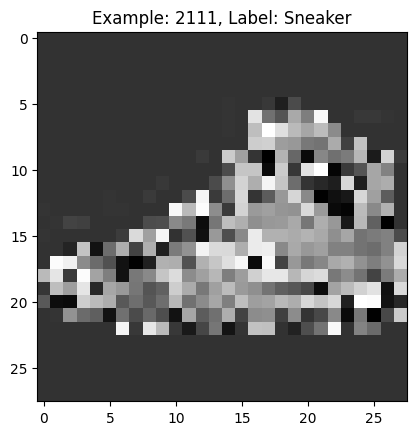

In [34]:
from matplotlib.image import NEAREST
# To solve this task you might want to have a look at the code of exercise 4.

#### Step 1. define "train" path ###############################################

train_path = data_directory + '/train_fmnist'

#### Step 2. define transformations and download the "train" dataset ############

# define pytorch transformation into tensor format (grey scale, so only one channel per mean & std)
transf = torchvision.transforms.Compose([torchvision.transforms.ToTensor(),torchvision.transforms.Normalize((0.2860,), (0.3530,))])

# download and transform training images
fmnist_train_data = torchvision.datasets.FashionMNIST(root=train_path, train=True, transform=transf, download=True)
print('Length of training dataset:')
print(len(fmnist_train_data))

#### Step 3. setup/define labels ################################################

fmnist_classes = {0: 'T-shirt/top',
                    1: 'Trouser',
                    2: 'Pullover',
                    3: 'Dress',
                    4: 'Coat',
                    5: 'Sandal',
                    6: 'Shirt',
                    7: 'Sneaker',
                    8: 'Bag',
                    9: 'Ankle boot'}

# Check with one example:
fmnist_train_data[2111]
fmnist_train_image, fmnist_train_label = fmnist_train_data[2111]
# number of class
print('Number of class:')
print(fmnist_train_label)
# assigned name of class
print('Assigned name of class:')
print(fmnist_classes[fmnist_train_label])

# Visualize this example
# Define tensor to image transformation
trans = torchvision.transforms.ToPILImage()
# set image plot title
plt.title('Example: {}, Label: {}'.format(str(2111), fmnist_classes[fmnist_train_label]))
# plot
plt.imshow(trans(fmnist_train_image), cmap='gray', interpolation='nearest')

#### Step 4. define "eval" path ################################################

eval_path = data_directory + '/eval_fmnist'

#### Step 5. define transformation and download the "eval" dataset #############
# define pytorch transformation into tensor format (also normalize)
transf = torchvision.transforms.Compose([torchvision.transforms.ToTensor(), torchvision.transforms.Normalize((0.2860,), (0.3530,))])

# download and transform eval images
fmnist_eval_data = torchvision.datasets.FashionMNIST(root=eval_path, train=False, transform=transf, download=True)
print('Length of eval dataset:')
print(len(fmnist_eval_data))

### 3.2 Convolutional Neural Network (CNN) Model Training and Evaluation

<img align="center" style="max-width: 900px" src="https://github.com/HSG-AIML-Teaching/GSERM2026-Lab/blob/main/assignment/process.png?raw=1">

Please note this image of a CNN was defined for the CIFAR-10 dataset. Your Fashion-MNIST images have a different size.


**1. Implement and train your "baseline" CNN.**

In [35]:
# To solve this task you might want to have a look at the code of exercise 5.
# Please note: the Fashion MNIST dataset only encompasses two dimensions per image (1 channel).
# Chosen SOTA: https://www.mdpi.com/2227-7390/12/20/3174: "However, to achieve the best results, we used a convolutional network of relatively simple architecture,
# including three convolutional layers, dropout layers, and two forward connection layers with the softmax function
# at the network output. [...]
# The convolutional layers are of the same type, with a dimension of 3 × 3 and Max Pooling with a dimension of 2 × 2."
# So I am modeling CNN-3-128

#### Step 1. define and init neural network architecture #############################################################

class fmnist_cnn(nn.Module):

  def __init__(self):
        # call super class constructor
        super(fmnist_cnn, self).__init__()

        # specify convolution layer 1 --> only 1 channel because pictures are greyscale
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=1, padding=0)
        # specify pooling layer 1 --> testing without stride parameter (default is stride = kernel size)
        self.pool1 = nn.MaxPool2d(kernel_size=2)
        # define dropout layer 1
        self.drop1 = nn.Dropout2d(p=0.25)
        # specify convolution layer 2
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=0)
        # define dropout layer 2
        self.drop2 = nn.Dropout2d(p=0.25)
        # specify pooling layer 2
        self.pool2 = nn.MaxPool2d(kernel_size=2)
        # specify convolution layer 3
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=0)
        # define dropout layer 3
        self.drop3 = nn.Dropout2d(p=0.4)

        # specify fc layer 1 - in 128 * 3 * 3, out 128
        self.linear1 = nn.Linear(128 * 3 * 3, 128, bias=True) # the linearity W*x+b
        self.relu1 = nn.ReLU(inplace=True) # the non-linearity
        self.drop_fc = nn.Dropout(p=0.3)

        # specify fc layer 2 (output layer) - in 128, out 10 = number of classes
        self.linear2 = nn.Linear(128, 10, bias=True)    # the linearity W*x+b

        # add a softmax to the last layer
        self.logsoftmax = nn.LogSoftmax(dim=1) # the softmax

  # define network forward pass
  def forward(self, images):

        # define conv layer 1 forward pass
        x = self.drop1(self.pool1(self.relu1(self.conv1(images))))

        # define conv layer 2 forward pass
        x = self.drop2(self.pool2(self.relu1(self.conv2(x))))

        # define conv layer 3 forward pass
        x = self.drop3(self.relu1(self.conv3(x)))

        # feature flattening

        # reshape image pixels
        x = x.view(-1, 128 * 3 * 3)

        # combination of feature learning via non-linear layers

        # define fc layer 1 forward pass
        x = self.drop_fc(self.relu1(self.linear1(x)))

        # define layer 2 forward pass
        x = self.logsoftmax(self.linear2(x))

        # return forward pass result
        return x

# Init model and move to GPU
model = fmnist_cnn()
model = model.to(device)
!nvidia-smi
# print the initialized architectures
print('[LOG] fmnist_cnn model architecture:\n\n{}\n'.format(model))
# init the number of model parameters
num_params = 0
# iterate over the distinct parameters
for param in model.parameters():
    # collect number of parameters
    num_params += param.numel()
# print the number of model paramters
print('[LOG] Number of to be trained fmnist_cnn model parameters: {}.'.format(num_params))

#### Step 2. define loss, training hyperparameters and dataloader ####################################################

# define the optimization criterion / loss function
nll_loss = nn.NLLLoss()
nll_loss = nll_loss.to(device)

# define learning rate and optimization strategy
# hyperparameters / training parameters
learning_rate = 0.001
num_epochs = 20 # number of training epochs
mini_batch_size = 128 # size of the mini-batches

optimizer = optim.SGD(params=model.parameters(), lr=learning_rate)

# dataloader
fmnist_train_dataloader = torch.utils.data.DataLoader(fmnist_train_data, batch_size=mini_batch_size, shuffle=True)


Thu Jul  9 10:34:32 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   54C    P0             28W /   70W |    2931MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

[LOG 20260709-10:34:47] epoch: 0 train-loss: 2.300543003753304
[LOG 20260709-10:35:02] epoch: 1 train-loss: 2.288637531337453
[LOG 20260709-10:35:16] epoch: 2 train-loss: 2.26993464051025
[LOG 20260709-10:35:31] epoch: 3 train-loss: 2.2329773831723343
[LOG 20260709-10:35:45] epoch: 4 train-loss: 2.1307060194930543
[LOG 20260709-10:36:00] epoch: 5 train-loss: 1.8699266539453698
[LOG 20260709-10:36:14] epoch: 6 train-loss: 1.5390404472981434
[LOG 20260709-10:36:29] epoch: 7 train-loss: 1.332630697598081
[LOG 20260709-10:36:44] epoch: 8 train-loss: 1.2089214354181594
[LOG 20260709-10:36:58] epoch: 9 train-loss: 1.1301151928362816
[LOG 20260709-10:37:13] epoch: 10 train-loss: 1.0687669013609002
[LOG 20260709-10:37:27] epoch: 11 train-loss: 1.020563002715487
[LOG 20260709-10:37:42] epoch: 12 train-loss: 0.97508170647916
[LOG 20260709-10:37:56] epoch: 13 train-loss: 0.9464815175101193
[LOG 20260709-10:38:11] epoch: 14 train-loss: 0.9155298218544103
[LOG 20260709-10:38:26] epoch: 15 train-los

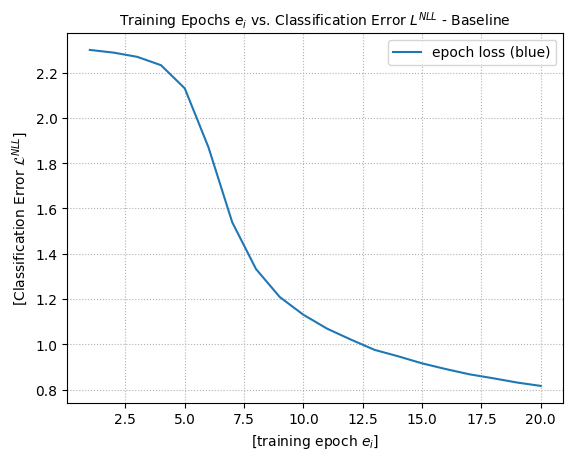

In [36]:
#### Step 3. run model training ######################################################################################

# init collection of training epoch losses
train_epoch_losses = []

# set the model in training mode
model.train()

# train the fmnist_cnn model
for epoch in range(num_epochs):

    # init collection of mini-batch losses
    train_mini_batch_losses = []

    # iterate over all-mini batches
    for i, (images, labels) in enumerate(fmnist_train_dataloader):

        # push mini-batch data to computation device
        images = images.to(device)
        labels = labels.to(device)

        # run forward pass through the network
        output = model(images)

        # reset graph gradients
        model.zero_grad()

        # determine classification loss
        loss = nll_loss(output, labels)

        # run backward pass
        loss.backward()

        # update network parameters
        optimizer.step()

        # collect mini-batch reconstruction loss
        train_mini_batch_losses.append(loss.data.item())

    # determine mean mini-batch loss of epoch
    train_epoch_loss = np.mean(train_mini_batch_losses)

    # print epoch loss
    now = datetime.now(UTC).strftime('%Y%m%d-%H:%M:%S')
    print('[LOG {}] epoch: {} train-loss: {}'.format(str(now), str(epoch), str(train_epoch_loss)))

    # set filename of actual model
    model_name = 'fmnist_model_epoch_{}.pth'.format(str(epoch))

    # save current model to GDrive models directory
    torch.save(model.state_dict(), os.path.join(models_directory, model_name))

    # determine mean min-batch loss of epoch
    train_epoch_losses.append(train_epoch_loss)

# prepare plot
fig = plt.figure()
ax = fig.add_subplot(111)

# add grid
ax.grid(linestyle='dotted')

# plot the training epochs vs. the epochs' classification error
ax.plot(np.array(range(1, len(train_epoch_losses)+1)), train_epoch_losses, label='epoch loss (blue)')

# add axis legends
ax.set_xlabel('[training epoch $e_i$]', fontsize=10)
ax.set_ylabel('[Classification Error $\\mathcal{L}^{NLL}$]', fontsize=10)

# set plot legend
plt.legend(loc="upper right", numpoints=1, fancybox=True)

# add plot title
plt.title('Training Epochs $e_i$ vs. Classification Error $L^{NLL}$ - Baseline', fontsize=10);

[LOG 20260709-10:39:32] eval-loss: 0.7201951742172241
0.7326


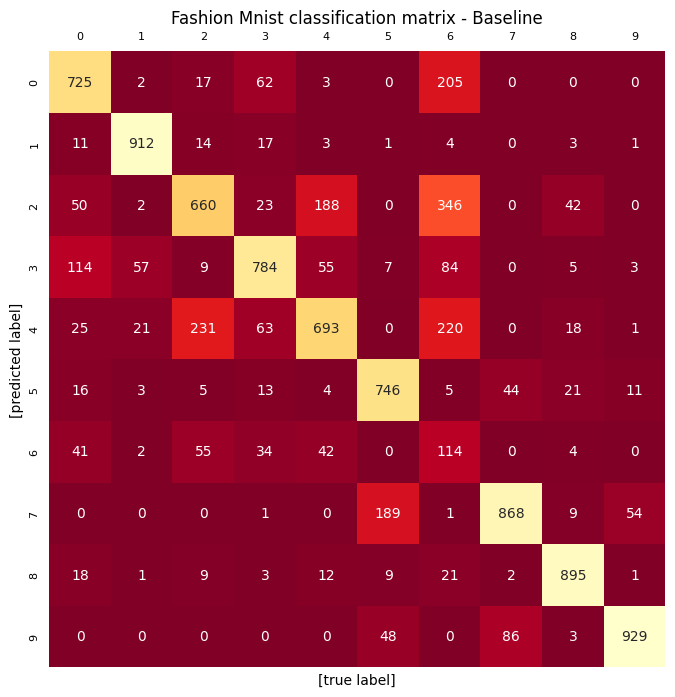

In [37]:
#### Step 4. run model evaluation ####################################################################################

# restore pre-trained model snapshot
best_model_name = models_directory + '/fmnist_model_epoch_19.pth'

# init pre-trained model class
best_model = fmnist_cnn()

# 2. Load the state dictionary
state_dict = torch.load(best_model_name, weights_only=True, map_location=torch.device('cpu'))

# 3. Insert the weights into the model
best_model.load_state_dict(state_dict)

# set model in evaluation mode
best_model.eval()

fmnist_eval_dataloader = torch.utils.data.DataLoader(fmnist_eval_data, batch_size=10000, shuffle=False)

# init collection of mini-batch losses
eval_mini_batch_losses = []
all_predictions = []

# iterate over all-mini batches
with torch.no_grad():
  for i, (images, labels) in enumerate(fmnist_eval_dataloader):

      # run forward pass through the network
      output = best_model(images)

      # determine classification loss
      loss = nll_loss(output, labels)

      # collect mini-batch reconstruction loss
      eval_mini_batch_losses.append(loss.item())

      # deduce predictions directly from forward pass to save RAM
      batch_predictions = torch.argmax(output,dim=1)
      all_predictions.append(batch_predictions)

# determine mean mini-batch loss of epoch
eval_loss = np.mean(eval_mini_batch_losses)

# print epoch loss
now = datetime.now(UTC).strftime('%Y%m%d-%H:%M:%S')
print('[LOG {}] eval-loss: {}'.format(str(now), str(eval_loss)))

predictions = torch.cat(all_predictions)

print(metrics.accuracy_score(fmnist_eval_data.targets, predictions))

# determine classification matrix of the predicted and target classes
mat = confusion_matrix(fmnist_eval_data.targets, predictions)

# initialize the plot and define size
plt.figure(figsize=(8, 8))

# plot corresponding confusion matrix
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False, cmap='YlOrRd_r', xticklabels=fmnist_classes, yticklabels=fmnist_classes)
plt.tick_params(axis='both', which='major', labelsize=8, labelbottom = False, bottom=False, top = False, left = False, labeltop=True)

# set plot title
plt.title('Fashion Mnist classification matrix - Baseline')

# set plot axis lables
plt.xlabel('[true label]')
plt.ylabel('[predicted label]');

**2. Implement and train your "improved" CNN.**
("improved" simply refers to a better classification accuracy than your baseline model)

In [38]:
# To solve this task you might want to have a look at the code of exercise 5.
# Some ideas might be the addition of layers, addition neurons or convolutions, longer training, smaller learning rate etc.

#### Step 1. define and init neural network architecture #############################################################

# Idea: Perform a very simple hyperparameter search for learning rate and optimizer, as this is not mentioned in the paper

class fmnist_cnn(nn.Module):

  def __init__(self):
        # call super class constructor
        super(fmnist_cnn, self).__init__()

        # specify convolution layer 1 --> only 1 channel because pictures are greyscale
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=1, padding=0)
        # specify pooling layer 1 --> testing without stride parameter (default is stride = kernel size)
        self.pool1 = nn.MaxPool2d(kernel_size=2)
        # define dropout layer 1
        self.drop1 = nn.Dropout2d(p=0.25)
        # specify convolution layer 2
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=0)
        # define dropout layer 2
        self.drop2 = nn.Dropout2d(p=0.25)
        # specify pooling layer 2
        self.pool2 = nn.MaxPool2d(kernel_size=2)
        # specify convolution layer 3
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=0)
        # define dropout layer 3
        self.drop3 = nn.Dropout2d(p=0.4)

        # specify fc layer 1 - in 128 * 3 * 3, out 128
        self.linear1 = nn.Linear(128 * 3 * 3, 128, bias=True) # the linearity W*x+b
        self.relu1 = nn.ReLU(inplace=True) # the non-linearity
        self.drop_fc = nn.Dropout(p=0.3)

        # specify fc layer 2 (output layer) - in 128, out 10 = number of classes
        self.linear2 = nn.Linear(128, 10, bias=True)    # the linearity W*x+b

        # add a softmax to the last layer
        self.logsoftmax = nn.LogSoftmax(dim=1) # the softmax

  # define network forward pass
  def forward(self, images):

        # define conv layer 1 forward pass
        x = self.drop1(self.pool1(self.relu1(self.conv1(images))))

        # define conv layer 2 forward pass
        x = self.drop2(self.pool2(self.relu1(self.conv2(x))))

        # define conv layer 3 forward pass
        x = self.drop3(self.relu1(self.conv3(x)))

        # feature flattening

        # reshape image pixels
        x = x.view(-1, 128 * 3 * 3)

        # combination of feature learning via non-linear layers

        # define fc layer 1 forward pass
        x = self.drop_fc(self.relu1(self.linear1(x)))

        # define layer 2 forward pass
        x = self.logsoftmax(self.linear2(x))

        # return forward pass result
        return x

# Init model and move to GPU
model = fmnist_cnn()
model = model.to(device)
!nvidia-smi
# print the initialized architectures
print('[LOG] fmnist_cnn model architecture:\n\n{}\n'.format(model))
# init the number of model parameters
num_params = 0
# iterate over the distinct parameters
for param in model.parameters():
    # collect number of parameters
    num_params += param.numel()
# print the number of model paramters
print('[LOG] Number of to be trained fmnist_cnn model parameters: {}.'.format(num_params))

#### Step 2. define loss, training hyperparameters and dataloader ####################################################

# define the optimization criterion / loss function
nll_loss = nn.NLLLoss()
nll_loss = nll_loss.to(device)

mini_batch_size = 128 # size of the mini-batches

optimizer = optim.Adam(params=model.parameters(), lr=0.001)

# dataloader
fmnist_train_dataloader = torch.utils.data.DataLoader(fmnist_train_data, batch_size=mini_batch_size, shuffle=True)
# also dataloader for eval data for grid search
fmnist_eval_dataloader = torch.utils.data.DataLoader(fmnist_eval_data, batch_size=10000, shuffle=False)


Thu Jul  9 10:39:32 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   64C    P0             30W /   70W |    2931MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [39]:
#### Improvement step: Grid search before training ###################################################################
# Grid search values for learning rate and optimizers
learning_rates = [0.001,0.003,0.01]
optimizers = ['adam', 'sgd_momentum']

results=[]

for lr, opt_name in itertools.product(learning_rates, optimizers):
  model = fmnist_cnn()
  model = model.to(device)

  if opt_name == 'adam':
    optimizer = optim.Adam(model.parameters(), lr=lr)
  else:
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum = 0.9)

  criterion = nn.NLLLoss()

  model.train()

  for epoch in range(5):
      for images, labels in fmnist_train_dataloader:

          # run forward pass through the network
          images = images.to(device)
          labels = labels.to(device)

          # run forward pass through the network
          output = model(images)

          # reset graph gradients
          optimizer.zero_grad()

          # determine classification loss
          loss = criterion(output, labels)

          # run backward pass
          loss.backward()

          optimizer.step()

  model.eval()
  correct_predictions, total = 0, 0
  with torch.no_grad():
    for images, labels in fmnist_eval_dataloader:

      # push mini-batch data to computation device
      images = images.to(device)
      labels =  labels.to(device)

      # run forward pass through the network
      output = model(images)

      predictions = torch.argmax(output, dim=1)

      correct_predictions += (predictions == labels).sum().item()

      total += labels.size(0)

  accuracy = correct_predictions / total
  print(f'lr={lr}, optimizer={opt_name}, resulted in Accuracy: {accuracy}')
  results.append((lr, opt_name, accuracy))

best_lr, best_optimizer_name, best_accuracy = max(results, key=lambda r: r[2])
print(f'Best Combination: lr = {best_lr}, optimizer={best_optimizer_name}, Accuracy={best_accuracy}')

lr=0.001, optimizer=adam, resulted in Accuracy: 0.8883
lr=0.001, optimizer=sgd_momentum, resulted in Accuracy: 0.7778
lr=0.003, optimizer=adam, resulted in Accuracy: 0.8924
lr=0.003, optimizer=sgd_momentum, resulted in Accuracy: 0.8256
lr=0.01, optimizer=adam, resulted in Accuracy: 0.8082
lr=0.01, optimizer=sgd_momentum, resulted in Accuracy: 0.8752
Best Combination: lr = 0.003, optimizer=adam, Accuracy=0.8924


[LOG 20260709-10:46:51] epoch: 0 train-loss: 0.6300615166296074
[LOG 20260709-10:47:06] epoch: 1 train-loss: 0.43836676972761335
[LOG 20260709-10:47:21] epoch: 2 train-loss: 0.3924044739526472
[LOG 20260709-10:47:37] epoch: 3 train-loss: 0.36658241817437764
[LOG 20260709-10:47:51] epoch: 4 train-loss: 0.3557763423746837
[LOG 20260709-10:48:06] epoch: 5 train-loss: 0.35079786349842546
[LOG 20260709-10:48:21] epoch: 6 train-loss: 0.34406079011939483
[LOG 20260709-10:48:37] epoch: 7 train-loss: 0.3390502269143489
[LOG 20260709-10:48:51] epoch: 8 train-loss: 0.33150261030522493
[LOG 20260709-10:49:06] epoch: 9 train-loss: 0.3276143430519714
[LOG 20260709-10:49:21] epoch: 10 train-loss: 0.3209310476777396
[LOG 20260709-10:49:36] epoch: 11 train-loss: 0.3223445123192598
[LOG 20260709-10:49:51] epoch: 12 train-loss: 0.31788124846242893
[LOG 20260709-10:50:07] epoch: 13 train-loss: 0.31564753033967413
[LOG 20260709-10:50:22] epoch: 14 train-loss: 0.31251114327261953
[LOG 20260709-10:50:37] epo

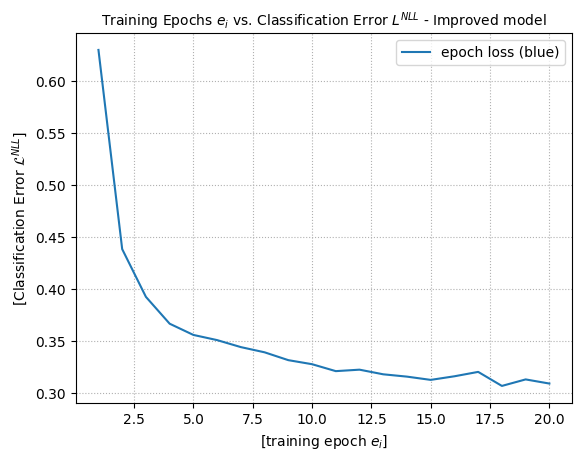

In [40]:
#### Step 3. run model training ######################################################################################

# init collection of training epoch losses
train_epoch_losses = []

# initialize model for final time
model = fmnist_cnn()
model = model.to(device)

# take best optimizer
if best_optimizer_name == 'adam':
  optimizer = optim.Adam(model.parameters(), lr = best_lr)
else:
  optimizer = optim.SGD(model.parameters(), lr = best_lr, momentum = 0.9)

# number of training epochs
num_epochs = 20

# train the fmnist_cnn model
for epoch in range(num_epochs):

    # init collection of mini-batch losses
    train_mini_batch_losses = []

    # iterate over all-mini batches
    for i, (images, labels) in enumerate(fmnist_train_dataloader):

        # push mini-batch data to computation device
        images = images.to(device)
        labels = labels.to(device)

        # run forward pass through the network
        output = model(images)

        # reset graph gradients
        model.zero_grad()

        # determine classification loss
        loss = nll_loss(output, labels)

        # run backward pass
        loss.backward()

        # update network parameters
        optimizer.step()

        # collect mini-batch reconstruction loss
        train_mini_batch_losses.append(loss.data.item())

    # determine mean mini-batch loss of epoch
    train_epoch_loss = np.mean(train_mini_batch_losses)

    # print epoch loss
    now = datetime.now(UTC).strftime('%Y%m%d-%H:%M:%S')
    print('[LOG {}] epoch: {} train-loss: {}'.format(str(now), str(epoch), str(train_epoch_loss)))

    # set filename of actual model
    model_name = 'fmnist_model_improved_epoch_{}.pth'.format(str(epoch))

    # save current model to GDrive models directory
    torch.save(model.state_dict(), os.path.join(models_directory, model_name))

    # determine mean min-batch loss of epoch
    train_epoch_losses.append(train_epoch_loss)

# prepare plot
fig = plt.figure()
ax = fig.add_subplot(111)

# add grid
ax.grid(linestyle='dotted')

# plot the training epochs vs. the epochs' classification error
ax.plot(np.array(range(1, len(train_epoch_losses)+1)), train_epoch_losses, label='epoch loss (blue)')

# add axis legends
ax.set_xlabel('[training epoch $e_i$]', fontsize=10)
ax.set_ylabel('[Classification Error $\\mathcal{L}^{NLL}$]', fontsize=10)

# set plot legend
plt.legend(loc='upper right', numpoints=1, fancybox=True)

# add plot title
plt.title('Training Epochs $e_i$ vs. Classification Error $L^{NLL}$ - Improved model', fontsize=10);

[LOG 20260709-10:51:43] eval-loss: 0.28720301389694214
0.8948


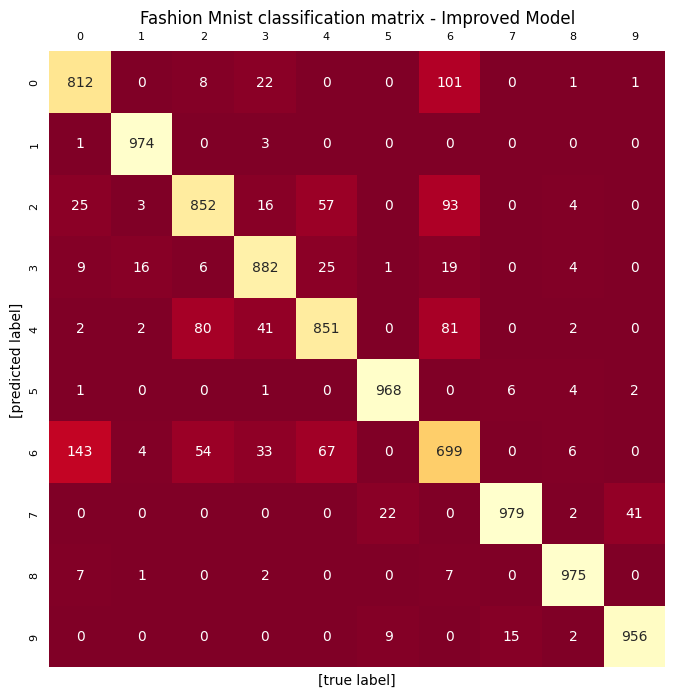

In [41]:
#### Step 4. run model evaluation ####################################################################################

# restore pre-trained model snapshot
best_model_name = models_directory + '/fmnist_model_improved_epoch_19.pth'

# init pre-trained model class
best_model = fmnist_cnn()

# 2. Load the state dictionary
state_dict = torch.load(best_model_name, weights_only=True, map_location=torch.device('cpu'))

# 3. Insert the weights into the model
best_model.load_state_dict(state_dict)

# set model in evaluation mode
best_model.eval()

fmnist_eval_dataloader = torch.utils.data.DataLoader(fmnist_eval_data, batch_size=10000, shuffle=False)

# init collection of mini-batch losses
eval_mini_batch_losses = []
all_predictions = []

# iterate over all-mini batches
with torch.no_grad():
  for i, (images, labels) in enumerate(fmnist_eval_dataloader):

      # run forward pass through the network
      output = best_model(images)

      # determine classification loss
      loss = nll_loss(output, labels)

      # collect mini-batch reconstruction loss
      eval_mini_batch_losses.append(loss.item())

      # deduce predictions directly from forward pass to save RAM
      batch_predictions = torch.argmax(output,dim=1)
      all_predictions.append(batch_predictions)

# determine mean mini-batch loss of epoch
eval_loss = np.mean(eval_mini_batch_losses)

# print epoch loss
now = datetime.now(UTC).strftime('%Y%m%d-%H:%M:%S')
print('[LOG {}] eval-loss: {}'.format(str(now), str(eval_loss)))

predictions = torch.cat(all_predictions)

print(metrics.accuracy_score(fmnist_eval_data.targets, predictions))

# determine classification matrix of the predicted and target classes
mat = confusion_matrix(fmnist_eval_data.targets, predictions)

# initialize the plot and define size
plt.figure(figsize=(8, 8))

# plot corresponding confusion matrix
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False, cmap='YlOrRd_r', xticklabels=fmnist_classes, yticklabels=fmnist_classes)
plt.tick_params(axis='both', which='major', labelsize=8, labelbottom = False, bottom=False, top = False, left = False, labeltop=True)

# set plot title
plt.title('Fashion Mnist classification matrix - Improved Model')

# set plot axis lables
plt.xlabel('[true label]')
plt.ylabel('[predicted label]');

In [42]:
# Retry with best HO combination, bigger model and longer training (epochs = 30)

#### Step 1. define and init neural network architecture #############################################################

class fmnist_cnn(nn.Module):

  def __init__(self):
        # call super class constructor
        super(fmnist_cnn, self).__init__()

        # specify convolution layer 1 --> only 1 channel because pictures are greyscale
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=128, kernel_size=3, stride=1, padding=0)
        # specify pooling layer 1 --> testing without stride parameter (default is stride = kernel size)
        self.pool1 = nn.MaxPool2d(kernel_size=2)
        # define dropout layer 1
        self.drop1 = nn.Dropout2d(p=0.25)
        # specify convolution layer 2
        self.conv2 = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, stride=1, padding=0)
        # define dropout layer 2
        self.drop2 = nn.Dropout2d(p=0.25)
        # specify pooling layer 2
        self.pool2 = nn.MaxPool2d(kernel_size=2)
        # specify convolution layer 3
        self.conv3 = nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3, stride=1, padding=0)
        # define dropout layer 3
        self.drop3 = nn.Dropout2d(p=0.4)

        # specify fc layer 1 - in 512 * 3 * 3, out 128
        self.linear1 = nn.Linear(512 * 3 * 3, 128, bias=True) # the linearity W*x+b
        self.relu1 = nn.ReLU(inplace=True) # the non-linearity
        self.drop_fc = nn.Dropout(p=0.3)

        # specify fc layer 2 (output layer) - in 128, out 10 = number of classes
        self.linear2 = nn.Linear(128, 10, bias=True)    # the linearity W*x+b

        # add a softmax to the last layer
        self.logsoftmax = nn.LogSoftmax(dim=1) # the softmax

  # define network forward pass
  def forward(self, images):

        # define conv layer 1 forward pass
        x = self.drop1(self.pool1(self.relu1(self.conv1(images))))

        # define conv layer 2 forward pass
        x = self.drop2(self.pool2(self.relu1(self.conv2(x))))

        # define conv layer 3 forward pass
        x = self.drop3(self.relu1(self.conv3(x)))

        # feature flattening

        # reshape image pixels
        x = x.view(-1, 512 * 3 * 3)

        # combination of feature learning via non-linear layers

        # define fc layer 1 forward pass
        x = self.drop_fc(self.relu1(self.linear1(x)))

        # define layer 2 forward pass
        x = self.logsoftmax(self.linear2(x))

        # return forward pass result
        return x

# Init model and move to GPU
model = fmnist_cnn()
model = model.to(device)
!nvidia-smi
# print the initialized architectures
print('[LOG] fmnist_cnn model architecture:\n\n{}\n'.format(model))
# init the number of model parameters
num_params = 0
# iterate over the distinct parameters
for param in model.parameters():
    # collect number of parameters
    num_params += param.numel()
# print the number of model paramters
print('[LOG] Number of to be trained fmnist_cnn model parameters: {}.'.format(num_params))

#### Step 2. define loss, training hyperparameters and dataloader ####################################################

# define the optimization criterion / loss function
nll_loss = nn.NLLLoss()
nll_loss = nll_loss.to(device)

# define learning rate and optimization strategy
# hyperparameters / training parameters
learning_rate = 0.001
num_epochs = 30 # number of training epochs
mini_batch_size = 128 # size of the mini-batches

optimizer = optim.Adam(params=model.parameters(), lr=learning_rate)

# dataloader
fmnist_train_dataloader = torch.utils.data.DataLoader(fmnist_train_data, batch_size=mini_batch_size, shuffle=True)

Thu Jul  9 10:51:43 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   76C    P0             34W /   70W |    2931MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

[LOG 20260709-10:24:38] epoch: 0 train-loss: 0.575102417453774
[LOG 20260709-10:24:57] epoch: 1 train-loss: 0.3780322473631231
[LOG 20260709-10:25:17] epoch: 2 train-loss: 0.32632933468071385
[LOG 20260709-10:25:36] epoch: 3 train-loss: 0.29649119759038056
[LOG 20260709-10:25:55] epoch: 4 train-loss: 0.2747509386430163
[LOG 20260709-10:26:14] epoch: 5 train-loss: 0.2602128597623758
[LOG 20260709-10:26:34] epoch: 6 train-loss: 0.2452522503224009
[LOG 20260709-10:26:54] epoch: 7 train-loss: 0.23352783251164563
[LOG 20260709-10:27:14] epoch: 8 train-loss: 0.224145227229036
[LOG 20260709-10:27:34] epoch: 9 train-loss: 0.21687249659792954
[LOG 20260709-10:27:54] epoch: 10 train-loss: 0.20378625200692016
[LOG 20260709-10:28:14] epoch: 11 train-loss: 0.19826335496485614
[LOG 20260709-10:28:33] epoch: 12 train-loss: 0.19062470058515382
[LOG 20260709-10:28:53] epoch: 13 train-loss: 0.1807580366095246
[LOG 20260709-10:29:12] epoch: 14 train-loss: 0.17873596495339103
[LOG 20260709-10:29:32] epoch

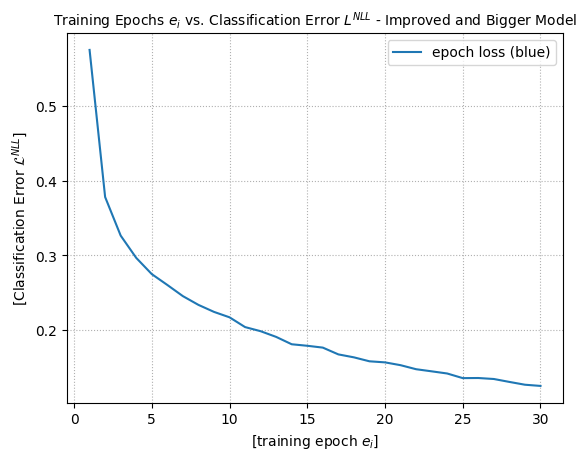

In [21]:
#### Step 3. run model training ######################################################################################

# init collection of training epoch losses
train_epoch_losses = []

# set the model in training mode
model.train()

# train the fmnist_cnn model
for epoch in range(num_epochs):

    # init collection of mini-batch losses
    train_mini_batch_losses = []

    # iterate over all-mini batches
    for i, (images, labels) in enumerate(fmnist_train_dataloader):

        # push mini-batch data to computation device
        images = images.to(device)
        labels = labels.to(device)

        # run forward pass through the network
        output = model(images)

        # reset graph gradients
        model.zero_grad()

        # determine classification loss
        loss = nll_loss(output, labels)

        # run backward pass
        loss.backward()

        # update network parameters
        optimizer.step()

        # collect mini-batch reconstruction loss
        train_mini_batch_losses.append(loss.data.item())

    # determine mean mini-batch loss of epoch
    train_epoch_loss = np.mean(train_mini_batch_losses)

    # print epoch loss
    now = datetime.now(UTC).strftime('%Y%m%d-%H:%M:%S')
    print('[LOG {}] epoch: {} train-loss: {}'.format(str(now), str(epoch), str(train_epoch_loss)))

    # set filename of actual model
    model_name = 'fmnist_model_epoch_bigger_and_improved_{}.pth'.format(str(epoch))

    # save current model to GDrive models directory
    torch.save(model.state_dict(), os.path.join(models_directory, model_name))

    # determine mean min-batch loss of epoch
    train_epoch_losses.append(train_epoch_loss)

# prepare plot
fig = plt.figure()
ax = fig.add_subplot(111)

# add grid
ax.grid(linestyle='dotted')

# plot the training epochs vs. the epochs' classification error
ax.plot(np.array(range(1, len(train_epoch_losses)+1)), train_epoch_losses, label='epoch loss (blue)')

# add axis legends
ax.set_xlabel('[training epoch $e_i$]', fontsize=10)
ax.set_ylabel('[Classification Error $\\mathcal{L}^{NLL}$]', fontsize=10)

# set plot legend
plt.legend(loc="upper right", numpoints=1, fancybox=True)

# add plot title
plt.title('Training Epochs $e_i$ vs. Classification Error $L^{NLL}$ - Improved and Bigger Model', fontsize=10);

[LOG 20260709-10:34:28] eval-loss: 0.26771554350852966
0.9228
[LOG 20260709-10:34:28] eval-loss: 0.26771554350852966
0.9228


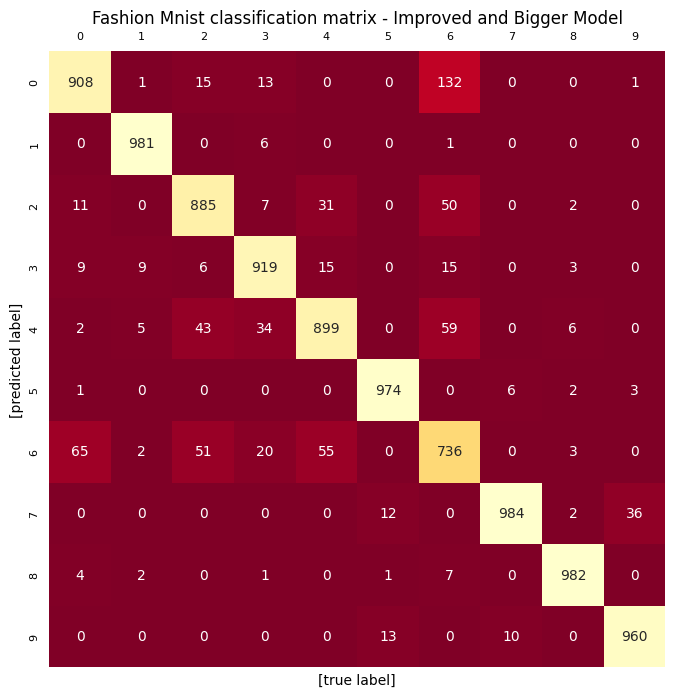

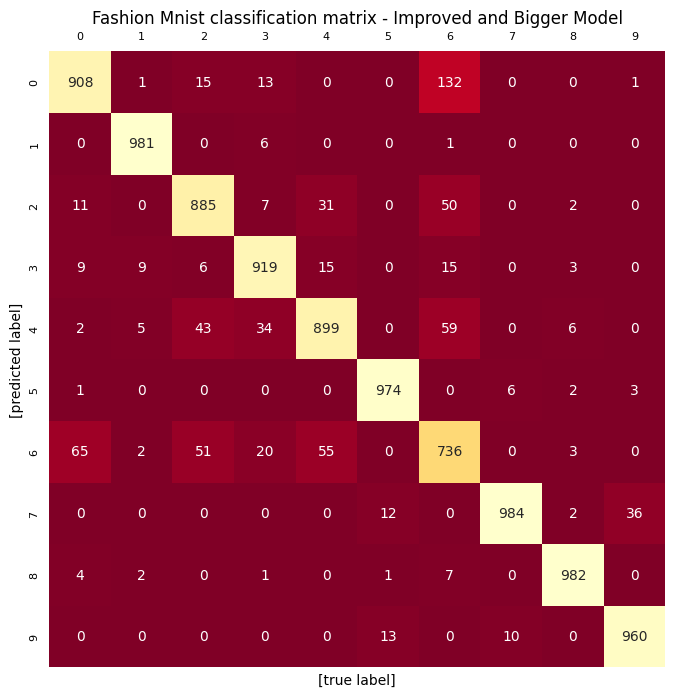

In [22]:
#### Step 4. run model evaluation ####################################################################################

# restore pre-trained model snapshot
best_model_name = models_directory + '/fmnist_model_epoch_bigger_and_improved_29.pth'

# init pre-trained model class
best_model = fmnist_cnn()

# 2. Load the state dictionary
state_dict = torch.load(best_model_name, weights_only=True, map_location=torch.device('cpu'))

# 3. Insert the weights into the model
best_model.load_state_dict(state_dict)

# set model in evaluation mode
best_model.eval()

fmnist_eval_dataloader = torch.utils.data.DataLoader(fmnist_eval_data, batch_size=10000, shuffle=False)

# init collection of mini-batch losses
eval_mini_batch_losses = []
all_predictions = []

# iterate over all-mini batches
with torch.no_grad():
  for i, (images, labels) in enumerate(fmnist_eval_dataloader):

      # run forward pass through the network
      output = best_model(images)

      # determine classification loss
      loss = nll_loss(output, labels)

      # collect mini-batch reconstruction loss
      eval_mini_batch_losses.append(loss.item())

      # deduce predictions directly from forward pass to save RAM
      batch_predictions = torch.argmax(output,dim=1)
      all_predictions.append(batch_predictions)

# determine mean mini-batch loss of epoch
eval_loss = np.mean(eval_mini_batch_losses)

# print epoch loss
now = datetime.now(UTC).strftime('%Y%m%d-%H:%M:%S')
print('[LOG {}] eval-loss: {}'.format(str(now), str(eval_loss)))

predictions = torch.cat(all_predictions)

print(metrics.accuracy_score(fmnist_eval_data.targets, predictions))

# determine classification matrix of the predicted and target classes
mat = confusion_matrix(fmnist_eval_data.targets, predictions)

# initialize the plot and define size
plt.figure(figsize=(8, 8))

# plot corresponding confusion matrix
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False, cmap='YlOrRd_r', xticklabels=fmnist_classes, yticklabels=fmnist_classes)
plt.tick_params(axis='both', which='major', labelsize=8, labelbottom = False, bottom=False, top = False, left = False, labeltop=True)

# set plot title
plt.title('Fashion Mnist classification matrix - Improved and Bigger Model')

# set plot axis lables
plt.xlabel('[true label]')
plt.ylabel('[predicted label]');